In [15]:
import pandas as pd

df = pd.read_csv("wdbc.data", header=None)

columns = ["ID", "Diagnosis",
            "radius_mean", "texture_mean", "perimeter_mean", "area_mean", "smoothness_mean",
            "compactness_mean", "concavity_mean", "concave_points_mean", "symmetry_mean", "fractal_dimension_mean",
            "radius_se", "texture_se", "perimeter_se", "area_se", "smoothness_se",
            "compactness_se", "concavity_se", "concave_points_se", "symmetry_se", "fractal_dimension_se",
            "radius_worst", "texture_worst", "perimeter_worst", "area_worst", "smoothness_worst",
            "compactness_worst", "concavity_worst", "concave_points_worst", "symmetry_worst", "fractal_dimension_worst"]

df.columns = columns

df.head()


,ID,Diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [16]:
from sklearn.preprocessing import StandardScaler

# Etiket ve ID sütunlarını çıkar (kümeleme denetimsiz olacak)
X = df.drop(["ID", "Diagnosis"], axis=1)

# Veriyi ölçekle
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Ölçeklenmiş verinin ilk 5 satırını gör
print(X_scaled[:5])


[[ 1.09706398e+00 -2.07333501e+00  1.26993369e+00  9.84374905e-01
   1.56846633e+00  3.28351467e+00  2.65287398e+00  2.53247522e+00
   2.21751501e+00  2.25574689e+00  2.48973393e+00 -5.65265059e-01
   2.83303087e+00  2.48757756e+00 -2.14001647e-01  1.31686157e+00
   7.24026158e-01  6.60819941e-01  1.14875667e+00  9.07083081e-01
   1.88668963e+00 -1.35929347e+00  2.30360062e+00  2.00123749e+00
   1.30768627e+00  2.61666502e+00  2.10952635e+00  2.29607613e+00
   2.75062224e+00  1.93701461e+00]
 [ 1.82982061e+00 -3.53632408e-01  1.68595471e+00  1.90870825e+00
  -8.26962447e-01 -4.87071673e-01 -2.38458552e-02  5.48144156e-01
   1.39236330e-03 -8.68652457e-01  4.99254601e-01 -8.76243603e-01
   2.63326966e-01  7.42401948e-01 -6.05350847e-01 -6.92926270e-01
  -4.40780058e-01  2.60162067e-01 -8.05450380e-01 -9.94437403e-02
   1.80592744e+00 -3.69203222e-01  1.53512599e+00  1.89048899e+00
  -3.75611957e-01 -4.30444219e-01 -1.46748968e-01  1.08708430e+00
  -2.43889668e-01  2.81189987e-01]
 [ 1.5

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, adjusted_rand_score, homogeneity_completeness_v_measure, confusion_matrix
from sklearn.decomposition import PCA

# Değerlendirme için gerçek etiketleri sayısal hale getir
# M=1 (malignant), B=0 (benign)
y_true = (df["Diagnosis"] == "M").astype(int).values


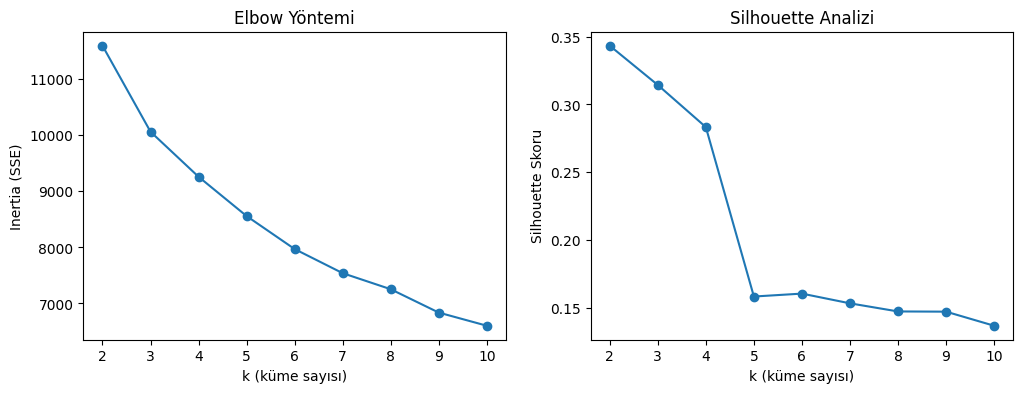

2

In [18]:
inertias = []
sil_scores = []
k_values = range(2, 11)

for k in k_values:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Elbow grafiği
ax[0].plot(k_values, inertias, marker='o')
ax[0].set_xlabel("k (küme sayısı)")
ax[0].set_ylabel("Inertia (SSE)")
ax[0].set_title("Elbow Yöntemi")

# Silhouette grafiği
ax[1].plot(k_values, sil_scores, marker='o')
ax[1].set_xlabel("k (küme sayısı)")
ax[1].set_ylabel("Silhouette Skoru")
ax[1].set_title("Silhouette Analizi")

plt.show()

best_k = k_values[int(np.argmax(sil_scores))]
best_k


[K-Means | k=2]
Adjusted Rand Index: 0.654
Homogeneity: 0.525 | Completeness: 0.540 | V-Measure: 0.532
Confusion Matrix (mapped):
 [[339  18]
 [ 36 176]]


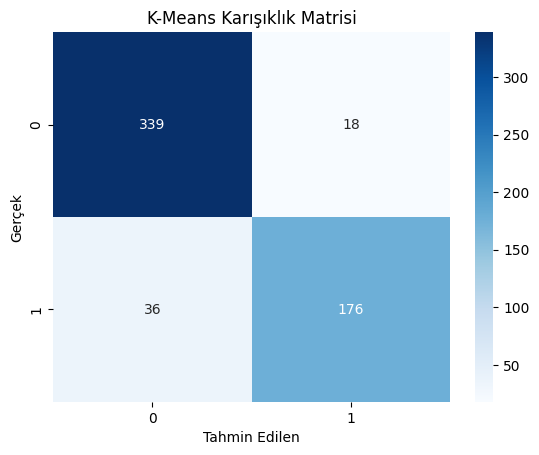

In [19]:
def map_clusters_to_truth(y_true, y_pred):
    """
    Her küme için en çok görülen gerçek sınıfa map'ler.
    Dönen dizi: y_pred_map (0/1) karşılaştırmaya hazır.
    """
    y_pred = np.asarray(y_pred)
    mapped = np.zeros_like(y_pred)
    for cluster in np.unique(y_pred):
        mask = (y_pred == cluster)
        if mask.sum() == 0:
            continue
        # Küme içindeki gerçek etiketlerin çoğunluğu
        majority = 1 if y_true[mask].sum() >= (mask.sum() - y_true[mask].sum()) else 0
        mapped[mask] = majority
    return mapped

# En iyi k ile K-Means
km = KMeans(n_clusters=best_k, n_init=10, random_state=42)
km_labels = km.fit_predict(X_scaled)

# Değerlendirme metrikleri
km_labels_mapped = map_clusters_to_truth(y_true, km_labels)

ari = adjusted_rand_score(y_true, km_labels)  # eşleşmeye duyarsız, direkt ham etiketlerle
h, c, v = homogeneity_completeness_v_measure(y_true, km_labels)  # ham etiketlerle
cm = confusion_matrix(y_true, km_labels_mapped)  # anlamlı karışıklık matrisi için map'lenmiş

print(f"[K-Means | k={best_k}]")
print(f"Adjusted Rand Index: {ari:.3f}")
print(f"Homogeneity: {h:.3f} | Completeness: {c:.3f} | V-Measure: {v:.3f}")
print("Confusion Matrix (mapped):\n", cm)
import seaborn as sns
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Tahmin Edilen")
plt.ylabel("Gerçek")
plt.title("K-Means Karışıklık Matrisi")
plt.show()



Best DBSCAN cfg: (np.float64(0.8000000000000003), 7) silhouette= 0.271


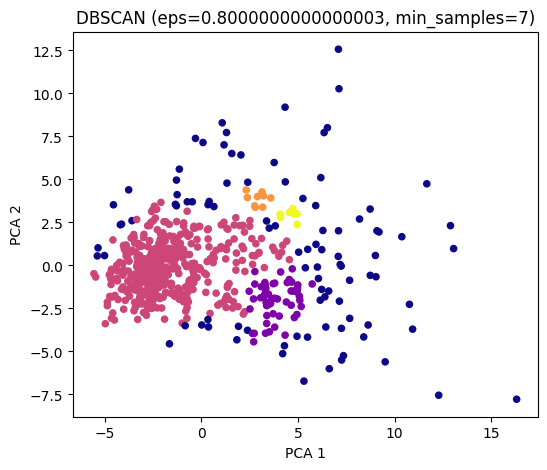

In [20]:
# 1️⃣ PCA
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 2️⃣ Parametre aralıkları
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

candidate_eps = np.arange(0.2, 1.0, 0.1)
candidate_min = [3, 5, 7]

# 3️⃣ Grid search
best_cfg = None
best_sil = -1
best_labels = None

for eps in candidate_eps:
    for ms in candidate_min:
        db = DBSCAN(eps=eps, min_samples=ms)
        labels = db.fit_predict(X_pca)
        if len(set(labels) - {-1}) < 2:
            continue
        try:
            sil = silhouette_score(X_pca, labels)
        except:
            sil = -1
        if sil > best_sil:
            best_sil = sil
            best_cfg = (eps, ms)
            best_labels = labels

print("Best DBSCAN cfg:", best_cfg, "silhouette=", round(best_sil, 3))

# 4️⃣ Görselleştirme
plt.figure(figsize=(6,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=best_labels, cmap='plasma', s=20)
plt.title(f"DBSCAN (eps={best_cfg[0]}, min_samples={best_cfg[1]})")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()


[DBSCAN | eps=0.8000000000000003, min_samples=7]
Adjusted Rand Index: 0.327
Homogeneity: 0.293 | Completeness: 0.220 | V-Measure: 0.251
Confusion Matrix (mapped):
 [[325  32]
 [ 80 132]]


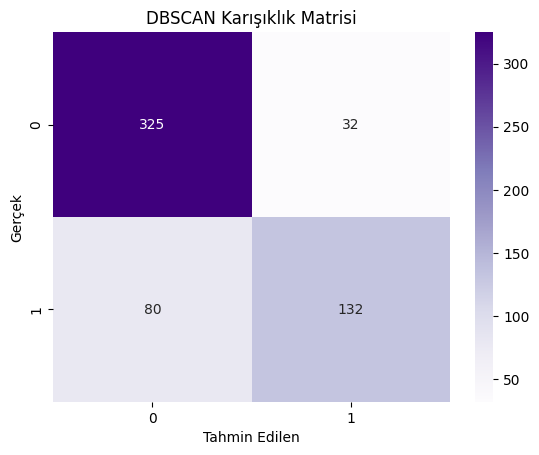

In [21]:
if best_labels is not None:
    db_labels = best_labels
    db_labels_mapped = map_clusters_to_truth(y_true, db_labels)

    # ARI / H-C-V ham etiketlerle (DBSCAN'de -1 (noise) olabilir, sorun değil)
    ari = adjusted_rand_score(y_true, db_labels)
    h, c, v = homogeneity_completeness_v_measure(y_true, db_labels)

    # Confusion matrix'i anlamlı görmek için -1 (noise) olanları bir sınıfa map'lemek gerekir.
    # Basitçe: noise'u ayrı bir küme gibi ele aldık, çoğunlukla map'leme fonksiyonu onu da 0/1'e atar.
    cm = confusion_matrix(y_true, db_labels_mapped)

    print(f"[DBSCAN | eps={best_cfg[0]}, min_samples={best_cfg[1]}]")
    print(f"Adjusted Rand Index: {ari:.3f}")
    print(f"Homogeneity: {h:.3f} | Completeness: {c:.3f} | V-Measure: {v:.3f}")
    print("Confusion Matrix (mapped):\n", cm)
else:
    print("DBSCAN için uygun (2+ küme) bir konfigürasyon bulunamadı. eps/min_samples aralığını genişlet.")


import seaborn as sns

sns.heatmap(cm, annot=True, fmt='d', cmap='Purples')
plt.xlabel("Tahmin Edilen")
plt.ylabel("Gerçek")
plt.title("DBSCAN Karışıklık Matrisi")
plt.show()


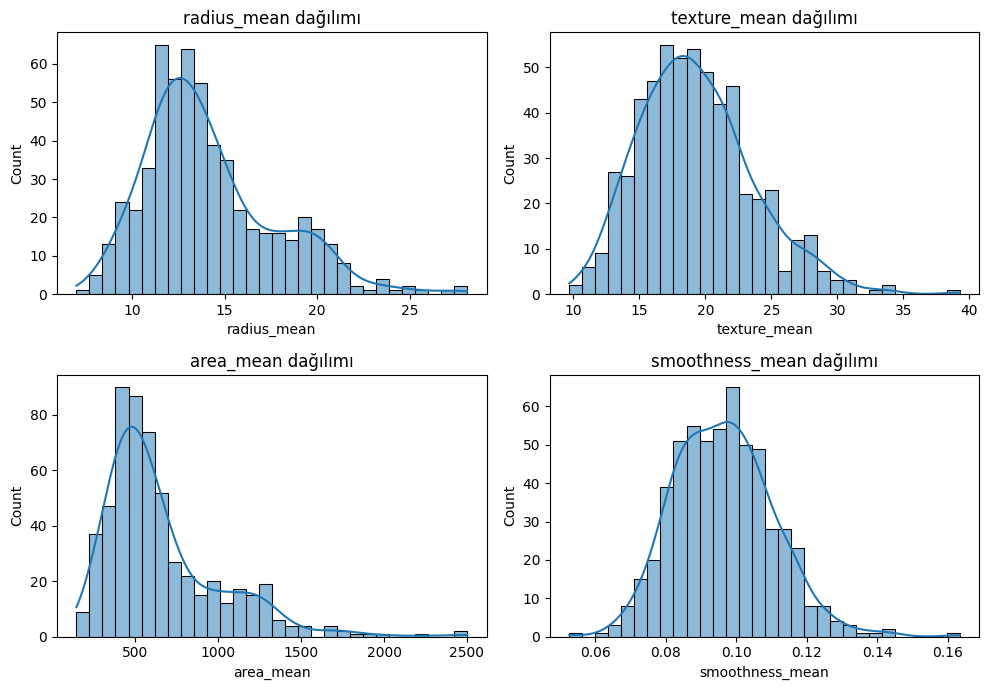

In [22]:
features_to_plot = ["radius_mean", "texture_mean", "area_mean", "smoothness_mean"]
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
axes = axes.ravel()

for i, feat in enumerate(features_to_plot):
    sns.histplot(df[feat], bins=30, ax=axes[i], kde=True)
    axes[i].set_title(f"{feat} dağılımı")

plt.tight_layout()
plt.show()


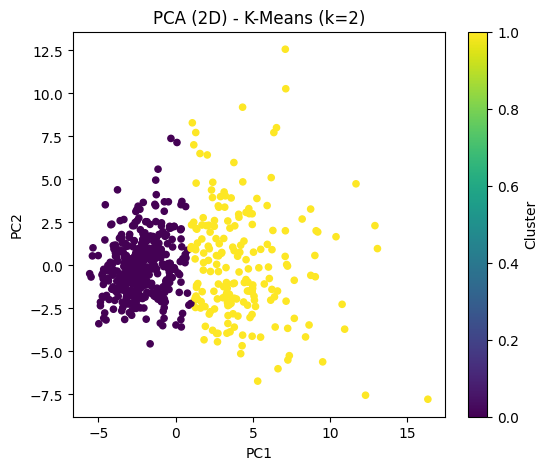

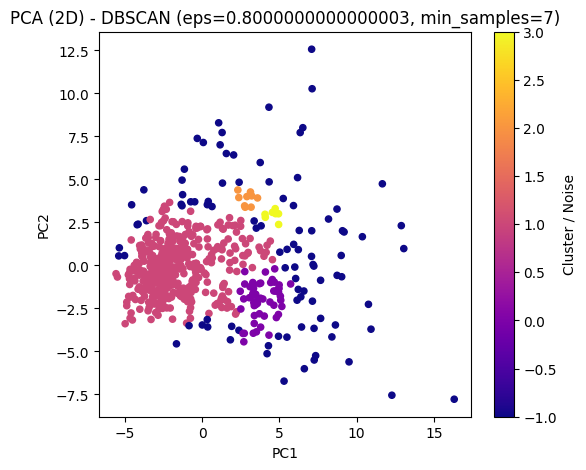

In [23]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# K-Means görseli
plt.figure(figsize=(6,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=km_labels, cmap='viridis', s=20)
plt.title(f"PCA (2D) - K-Means (k={best_k})")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="Cluster")
plt.show()

if best_labels is not None:
    plt.figure(figsize=(6,5))
    plt.scatter(X_pca[:,0], X_pca[:,1], c=best_labels, cmap='plasma', s=20)
    plt.title(f"PCA (2D) - DBSCAN (eps={best_cfg[0]}, min_samples={best_cfg[1]})")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.colorbar(label="Cluster / Noise")
    plt.show()



In [24]:
import numpy as np
from sklearn.metrics import silhouette_score

labels = best_labels if 'best_labels' in globals() and best_labels is not None else db_labels

# Küme ve örnek sayıları
unique, counts = np.unique(labels, return_counts=True)
print("Kümeler:", dict(zip(unique, counts)))

# Noise oranı
n_total = len(labels)
n_noise = counts[unique.tolist().index(-1)] if -1 in unique else 0
print(f"Noise oranı: {n_noise/n_total:.2%}")

# Silhouette (en az 2 küme varsa ve tümü aynı etiket değilse)
valid = set(labels) - {-1}
if len(valid) >= 2:
    sil = silhouette_score(X_scaled, labels)
    print("Silhouette:", round(sil, 3))
else:
    print("Silhouette hesaplanamadı (yeterli küme yok).")


Kümeler: {np.int64(-1): np.int64(95), np.int64(0): np.int64(53), np.int64(1): np.int64(405), np.int64(2): np.int64(9), np.int64(3): np.int64(7)}
Noise oranı: 16.70%
Silhouette: 0.18


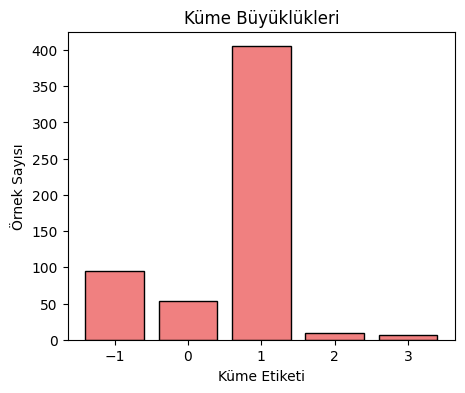

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))
plt.bar(unique, counts, color='lightcoral', edgecolor='black')
plt.title("Küme Büyüklükleri")
plt.xlabel("Küme Etiketi")
plt.ylabel("Örnek Sayısı")
plt.show()
